# Bird Counter - Auto Threshold with Dynamic ROI

This notebook implements bird detection with:
- **Dynamic ROI**: Automatically adjusts to scene changes using Sobel-based horizon detection
- **Enhanced Sky Color Detection**: Works across various sky conditions
- **Cloud Rejection**: Analyzes texture and edges to distinguish clouds from birds
- **Improved Motion Analysis**: Uses optical flow to detect bird-like movement
- **Flight Pattern Analysis**: Evaluates movement patterns typical of birds
- **Video Output**: Saves annotated video with bounding boxes

## Usage
1. Set the `VIDEO_PATH` variable in the configuration cell below
2. Run all cells in order
3. The output video with detections will be saved and displayed

In [1]:
# Import all required libraries
import cv2
import numpy as np
import math
import os
import time
from datetime import datetime
import warnings
from IPython.display import display, HTML, clear_output, Video
import matplotlib.pyplot as plt
from PIL import Image
import io
import base64

# Suppress runtime warnings for sqrt of negative numbers
warnings.filterwarnings('ignore', category=RuntimeWarning)

# For inline display of images
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================================
# CONFIGURATION - SET YOUR VIDEO PATH HERE
# ============================================================================

# VIDEO_PATH = "C_7142025_2(2) (online-video-cutter.com).mp4"  # <-- CHANGE THIS to your video file path

VIDEO_PATH = "E_7292025_1.MP4"
# Output settings
SAVE_OUTPUT_VIDEO = True  # Set to True to save video with bounding boxes
DISPLAY_LIVE_FRAMES = True  # Set to True to show frames while processing
DISPLAY_EVERY_N_FRAMES = 10  # Display every Nth frame (higher = faster processing)

# Example paths:
# VIDEO_PATH = "/Users/vaishnavis/Downloads/my_video.mp4"
# VIDEO_PATH = "C_7142025_2 (online-video-cutter.com) (1).mp4"

# ============================================================================

In [3]:
# ======================== DETECTION PARAMETERS ========================
FRAME_SKIP = 1  # Process every frame
RESIZE_FACTOR = 0.8  # Resize for processing

# --- Auto-ROI Parameters ---
ROI_UPDATE_INTERVAL = 12  # Frames to wait before re-calculating ROI
ROI_SMOOTHING_FACTOR = 0.5  # Smoothing for dynamic ROI changes
INITIAL_ROI_BOTTOM_PERCENTAGE = 60  # Default if auto-detection fails

# ROI parameters (will be updated dynamically)
ROI_TOP_PERCENTAGE = 0  # Start analyzing from the top
ROI_BOTTOM_PERCENTAGE = INITIAL_ROI_BOTTOM_PERCENTAGE

# Bird detection parameters
MIN_BIRD_AREA = 15
MAX_BIRD_AREA = 800
MIN_ASPECT_RATIO = 0.4
MAX_ASPECT_RATIO = 3.0

# Motion detection parameters
MOTION_THRESHOLD = 10
MIN_MOTION_PIXELS = 5
MAX_STATIONARY_FRAMES = 10
MIN_MOVEMENT_DISTANCE = 15
MIN_FLIGHT_DURATION = 3
MAX_MATCHING_DISTANCE = 80

# Cloud rejection parameters
CLOUD_TEXTURE_THRESHOLD = 20
MIN_BIRD_SOLIDITY = 0.6
MIN_BIRD_SPEED = 3
MAX_BIRD_SPEED = 100
DIRECTIONAL_CHANGE_THRESHOLD = 0.7
TEXTURE_NEIGHBORHOOD = 7

print("Parameters configured!")
print(f"- Frame Skip: {FRAME_SKIP}")
print(f"- Resize Factor: {RESIZE_FACTOR}")
print(f"- Initial ROI: {ROI_TOP_PERCENTAGE}% to {INITIAL_ROI_BOTTOM_PERCENTAGE}%")
print(f"- ROI Update Interval: Every {ROI_UPDATE_INTERVAL} frames")
print(f"- Save Output Video: {SAVE_OUTPUT_VIDEO}")
print(f"- Display Live Frames: {DISPLAY_LIVE_FRAMES}")

Parameters configured!
- Frame Skip: 1
- Resize Factor: 0.8
- Initial ROI: 0% to 60%
- ROI Update Interval: Every 12 frames
- Save Output Video: True
- Display Live Frames: True


In [4]:
def analyze_and_set_roi(frame, current_roi_bottom_percentage):
    """Analyzes the frame to find the horizon and dynamically set the ROI."""
    height, width = frame.shape[:2]
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (21, 21), 0)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=5)
    sobel_y = cv2.convertScaleAbs(sobel_y)
    vertical_projection = np.sum(sobel_y, axis=1)
    
    try:
        peak_density_y = np.argmax(vertical_projection)
        
        if peak_density_y >= len(vertical_projection) - 1:
            return current_roi_bottom_percentage
        
        remaining = vertical_projection[peak_density_y:]
        if len(remaining) == 0:
            return current_roi_bottom_percentage
            
        threshold = np.percentile(remaining, 10)
        
        horizon_y = peak_density_y
        for y in range(peak_density_y, 0, -1):
            if vertical_projection[y] < threshold:
                horizon_y = y
                break
        
        new_roi_bottom_percentage = (horizon_y / height) * 100
        smoothed_roi = (current_roi_bottom_percentage * (1 - ROI_SMOOTHING_FACTOR) + 
                        new_roi_bottom_percentage * ROI_SMOOTHING_FACTOR)
        smoothed_roi = max(20, min(95, smoothed_roi))
        
        return smoothed_roi
    except Exception as e:
        return current_roi_bottom_percentage

print("ROI functions defined!")

ROI functions defined!


In [5]:
def is_sky_color_improved(frame, bbox, roi_bottom_pct):
    """Improved sky color detection that better handles various sky conditions"""
    x, y, w, h = bbox
    frame_height, frame_width = frame.shape[:2]
    
    roi_top = int(frame_height * ROI_TOP_PERCENTAGE / 100)
    roi_bottom = int(frame_height * roi_bottom_pct / 100)
    
    if y < roi_top or y > roi_bottom:
        return False
    
    border = 10
    x1 = max(0, x - border)
    y1 = max(0, y - border)
    x2 = min(frame_width, x + w + border)
    y2 = min(frame_height, y + h + border)
    
    region = frame[y1:y2, x1:x2]
    
    if region.size == 0:
        return False
    
    hsv_region = cv2.cvtColor(region, cv2.COLOR_BGR2HSV)
    
    avg_saturation = np.mean(hsv_region[:, :, 1])
    avg_value = np.mean(hsv_region[:, :, 2])
    avg_hue = np.mean(hsv_region[:, :, 0])
    
    if avg_saturation < 60 and avg_value > 140:
        return True
    if 85 < avg_hue < 135 and avg_saturation < 160 and avg_value > 80:
        return True
    if 75 < avg_hue < 105 and avg_saturation < 120 and avg_value > 100:
        return True
    if avg_saturation < 30 and 80 < avg_value < 190:
        return True
    
    return False


def is_likely_cloud(frame, bbox):
    """Detect if a region is likely a cloud based on texture and color variance"""
    x, y, w, h = bbox
    
    if w < 10 or h < 10:
        return False
    
    frame_h, frame_w = frame.shape[:2]
    x = max(0, x)
    y = max(0, y)
    x2 = min(frame_w, x + w)
    y2 = min(frame_h, y + h)
    
    if x2 <= x or y2 <= y:
        return False
    
    region = frame[y:y2, x:x2]
    
    if region.size == 0:
        return False
    
    gray_region = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
    
    texture_kernel = np.ones((TEXTURE_NEIGHBORHOOD, TEXTURE_NEIGHBORHOOD), np.float32) / (TEXTURE_NEIGHBORHOOD * TEXTURE_NEIGHBORHOOD)
    local_mean = cv2.filter2D(gray_region.astype(np.float32), -1, texture_kernel)
    local_sqr_mean = cv2.filter2D(np.square(gray_region.astype(np.float32)), -1, texture_kernel)
    
    variance = local_sqr_mean - np.square(local_mean)
    variance = np.clip(variance, 0, None)
    local_std = np.sqrt(variance)
    
    avg_texture = np.mean(local_std)
    
    hsv_region = cv2.cvtColor(region, cv2.COLOR_BGR2HSV)
    color_std = np.std(hsv_region[:, :, 1])
    
    edges = cv2.Canny(gray_region, 50, 150)
    edge_density = np.count_nonzero(edges) / max(1, region.size)
    
    if (avg_texture < CLOUD_TEXTURE_THRESHOLD and 
        color_std < 25 and 
        edge_density < 0.05):
        return True
    
    return False


def calculate_object_solidity(contour):
    """Calculate solidity (area/convex hull area)"""
    area = cv2.contourArea(contour)
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    
    if hull_area > 0:
        return float(area) / hull_area
    return 0

print("Detection functions defined!")

Detection functions defined!


In [6]:
def detect_motion_improved(current_detections, frame, prev_gray_frame):
    """Improved motion detection that better distinguishes bird movement from clouds"""
    current_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    if prev_gray_frame is None:
        return [], current_gray
    
    flow = cv2.calcOpticalFlowFarneback(prev_gray_frame, current_gray, None, 
                                         0.5, 3, 15, 3, 5, 1.2, 0)
    
    frame_diff = cv2.absdiff(prev_gray_frame, current_gray)
    
    moving_birds = []
    for detection in current_detections:
        x, y, w, h = detection['bbox']
        
        if x < 0 or y < 0 or x+w >= frame.shape[1] or y+h >= frame.shape[0]:
            continue
        
        roi_diff = frame_diff[y:y+h, x:x+w]
        
        if roi_diff.size == 0:
            continue
        
        motion_pixels = np.count_nonzero(roi_diff > MOTION_THRESHOLD)
        
        roi_flow = flow[y:y+h, x:x+w]
        
        if roi_flow.size == 0:
            continue
        
        mag, ang = cv2.cartToPolar(roi_flow[..., 0], roi_flow[..., 1])
        avg_magnitude = np.mean(mag)
        
        if np.count_nonzero(mag > 0.5) > 10:
            flow_x = np.mean(roi_flow[..., 0])
            flow_y = np.mean(roi_flow[..., 1])
            flow_consistency = math.sqrt(flow_x**2 + flow_y**2) / (avg_magnitude + 1e-5)
        else:
            flow_consistency = 1.0
        
        if (motion_pixels >= MIN_MOTION_PIXELS and 
            MIN_BIRD_SPEED < avg_magnitude < MAX_BIRD_SPEED and 
            (flow_consistency < DIRECTIONAL_CHANGE_THRESHOLD or not is_likely_cloud(frame, detection['bbox']))):
            
            detection['motion_score'] = avg_magnitude
            detection['motion_pixels'] = motion_pixels
            detection['flow_consistency'] = flow_consistency
            moving_birds.append(detection)
    
    return moving_birds, current_gray


def detect_birds_improved(frame):
    """Improved bird detection with enhanced shape and texture analysis"""
    height, width = frame.shape[:2]
    
    if RESIZE_FACTOR != 1.0:
        new_width = int(width * RESIZE_FACTOR)
        new_height = int(height * RESIZE_FACTOR)
        resized_frame = cv2.resize(frame, (new_width, new_height))
        scale_x = width / new_width
        scale_y = height / new_height
    else:
        resized_frame = frame
        scale_x = scale_y = 1.0
    
    gray = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    detections = []
    for contour in contours:
        area = cv2.contourArea(contour)
        
        if MIN_BIRD_AREA < area < MAX_BIRD_AREA:
            x, y, w, h = cv2.boundingRect(contour)
            
            x = int(x * scale_x)
            y = int(y * scale_y)
            w = int(w * scale_x)
            h = int(h * scale_y)
            
            aspect_ratio = w / h if h > 0 else 0
            if MIN_ASPECT_RATIO < aspect_ratio < MAX_ASPECT_RATIO:
                solidity = calculate_object_solidity(contour)
                
                if solidity < MIN_BIRD_SOLIDITY:
                    continue
                
                if is_likely_cloud(frame, (x, y, w, h)):
                    continue
                
                center_x = x + w // 2
                center_y = y + h // 2
                
                detection = {
                    'bbox': (x, y, w, h),
                    'center': (center_x, center_y),
                    'area': area,
                    'solidity': solidity,
                    'aspect_ratio': aspect_ratio
                }
                detections.append(detection)
    
    return detections

print("Motion and bird detection functions defined!")

Motion and bird detection functions defined!


In [7]:
class ImprovedBirdTracker:
    def __init__(self):
        self.tracks = {}
        self.track_id = 0
        self.confirmed_flying_birds = set()
        
    def update_tracks(self, detections):
        """Improved tracking with flight pattern analysis"""
        matched_tracks = {}
        current_frame_birds = []
        
        for detection in detections:
            x, y = detection['center']
            best_match = None
            min_distance = float('inf')
            
            for track_id, track_data in self.tracks.items():
                if track_id not in matched_tracks and len(track_data['positions']) > 0:
                    last_pos = track_data['positions'][-1]
                    distance = math.sqrt((x - last_pos[0])**2 + (y - last_pos[1])**2)
                    
                    if distance < min_distance and distance < MAX_MATCHING_DISTANCE:
                        min_distance = distance
                        best_match = track_id
            
            if best_match:
                self.tracks[best_match]['positions'].append((x, y))
                self.tracks[best_match]['stationary_count'] = 0
                
                if 'detections' not in self.tracks[best_match]:
                    self.tracks[best_match]['detections'] = []
                self.tracks[best_match]['detections'].append(detection)
                
                matched_tracks[best_match] = detection
                
                if self.is_flying_improved(best_match):
                    self.confirmed_flying_birds.add(best_match)
                    current_frame_birds.append(detection)
            else:
                self.tracks[self.track_id] = {
                    'positions': [(x, y)],
                    'stationary_count': 0,
                    'detections': [detection]
                }
                self.track_id += 1
        
        tracks_to_remove = []
        for track_id, track_data in self.tracks.items():
            if track_id not in matched_tracks:
                track_data['stationary_count'] += 1
                if track_data['stationary_count'] >= MAX_STATIONARY_FRAMES:
                    tracks_to_remove.append(track_id)
        
        for track_id in tracks_to_remove:
            del self.tracks[track_id]
        
        return current_frame_birds
    
    def is_flying_improved(self, track_id):
        """Improved flying detection with flight pattern analysis"""
        positions = self.tracks[track_id]['positions']
        
        if len(positions) < MIN_FLIGHT_DURATION:
            return False
        
        total_distance = 0
        for i in range(1, len(positions)):
            prev_pos = positions[i-1]
            curr_pos = positions[i]
            distance = math.sqrt((curr_pos[0] - prev_pos[0])**2 + (curr_pos[1] - prev_pos[1])**2)
            total_distance += distance
        
        directions = []
        for i in range(1, len(positions)):
            prev_pos = positions[i-1]
            curr_pos = positions[i]
            dx = curr_pos[0] - prev_pos[0]
            dy = curr_pos[1] - prev_pos[1]
            
            if dx != 0 or dy != 0:
                angle = math.atan2(dy, dx)
                directions.append(angle)
        
        direction_changes = 0
        if len(directions) > 2:
            for i in range(1, len(directions)):
                diff = abs(directions[i] - directions[i-1])
                if diff > math.pi:
                    diff = 2 * math.pi - diff
                if diff > 0.3:
                    direction_changes += 1
        
        good_bird_features = 0
        if 'detections' in self.tracks[track_id] and len(self.tracks[track_id]['detections']) > 0:
            detections = self.tracks[track_id]['detections']
            
            if any('motion_score' in d for d in detections):
                motion_scores = [d.get('motion_score', 0) for d in detections if 'motion_score' in d]
                if motion_scores and np.mean(motion_scores) > MIN_BIRD_SPEED:
                    good_bird_features += 1
            
            if any('flow_consistency' in d for d in detections):
                flow_consistencies = [d.get('flow_consistency', 1.0) for d in detections if 'flow_consistency' in d]
                if flow_consistencies and np.mean(flow_consistencies) < DIRECTIONAL_CHANGE_THRESHOLD:
                    good_bird_features += 1
            
            if any('aspect_ratio' in d for d in detections):
                aspect_ratios = [d.get('aspect_ratio', 0) for d in detections if 'aspect_ratio' in d]
                if aspect_ratios and np.std(aspect_ratios) > 0.1:
                    good_bird_features += 1
        
        return (total_distance > MIN_MOVEMENT_DISTANCE and 
                (direction_changes > 0 or good_bird_features >= 1))
    
    def get_unique_flying_birds_count(self):
        return len(self.confirmed_flying_birds)

print("Tracker class defined!")

Tracker class defined!


In [8]:
def draw_detections(frame, current_detections, sky_detections, moving_detections, 
                    currently_flying_birds, current_roi_bottom, unique_count, frame_count, total_frames):
    """Draw bounding boxes and information on frame"""
    display_frame = frame.copy()
    height, width = frame.shape[:2]
    
    # Draw ROI lines
    roi_top = int(height * ROI_TOP_PERCENTAGE / 100)
    roi_bottom = int(height * current_roi_bottom / 100)
    cv2.line(display_frame, (0, roi_top), (width, roi_top), (255, 255, 0), 2)
    cv2.line(display_frame, (0, roi_bottom), (width, roi_bottom), (255, 0, 255), 2)
    
    # Draw all initial detections (cyan - thin)
    for detection in current_detections:
        x, y, w, h = detection['bbox']
        cv2.rectangle(display_frame, (x, y), (x + w, y + h), (255, 255, 0), 1)
    
    # Draw sky-filtered detections (yellow)
    for detection in sky_detections:
        x, y, w, h = detection['bbox']
        cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 255, 255), 1)
    
    # Draw moving detections (green)
    for detection in moving_detections:
        x, y, w, h = detection['bbox']
        cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        motion_score = detection.get('motion_score', 0)
        cv2.putText(display_frame, f"M:{motion_score:.1f}", (x, y - 5), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (57, 255, 20), 2)
    
    # Draw confirmed flying birds (red - thick)
    for detection in currently_flying_birds:
        x, y, w, h = detection['bbox']
        cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 0, 255), 3)
        cv2.putText(display_frame, "FLYING", (x, y - 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    
    # Colors: neon green, white, light blue (BGR)
    NEON_GREEN = (57, 255, 20)
    WHITE = (255, 255, 255)
    LIGHT_BLUE = (255, 220, 100)

    # Draw info panel
    cv2.rectangle(display_frame, (5, 5), (430, 245), (0, 0, 0), -1)
    cv2.rectangle(display_frame, (5, 5), (430, 245), NEON_GREEN, 2)

    cv2.putText(display_frame, f"Frame: {frame_count}/{total_frames}",
               (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.85, WHITE, 2)
    cv2.putText(display_frame, f"UNIQUE Flying Birds: {unique_count}",
               (10, 72), cv2.FONT_HERSHEY_SIMPLEX, 1.0, NEON_GREEN, 3)
    cv2.putText(display_frame, f"ROI Bottom: {current_roi_bottom:.1f}%",
               (10, 108), cv2.FONT_HERSHEY_SIMPLEX, 0.85, LIGHT_BLUE, 2)
    cv2.putText(display_frame, f"Detections: {len(current_detections)}",
               (10, 142), cv2.FONT_HERSHEY_SIMPLEX, 0.85, WHITE, 2)
    cv2.putText(display_frame, f"Sky-filtered: {len(sky_detections)}",
               (10, 176), cv2.FONT_HERSHEY_SIMPLEX, 0.85, LIGHT_BLUE, 2)
    cv2.putText(display_frame, f"Moving: {len(moving_detections)}",
               (10, 210), cv2.FONT_HERSHEY_SIMPLEX, 0.85, NEON_GREEN, 2)
    cv2.putText(display_frame, f"Flying now: {len(currently_flying_birds)}",
               (10, 244), cv2.FONT_HERSHEY_SIMPLEX, 0.85, NEON_GREEN, 2)
    
    # Legend at bottom
    legend_y = height - 10
    cv2.putText(display_frame, "Yellow ROI | Magenta ROI | Cyan=Initial | Yellow=Sky | Green=Moving | Red=FLYING", 
               (10, legend_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, WHITE, 2)
    
    return display_frame


def display_frame_inline(frame, figsize=(12, 8)):
    """Display a frame inline in Jupyter notebook"""
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Visualization functions defined!")

Visualization functions defined!


In [9]:
def process_video_with_visualization(video_path, save_output=True, display_live=True, display_interval=10):
    """Process video with visualization - saves output video and displays frames"""
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Processing: {os.path.basename(video_path)}")
    print(f"- Resolution: {width}x{height}")
    print(f"- FPS: {fps}, Total Frames: {total_frames}")
    print(f"- Duration: {total_frames/fps:.1f} seconds")
    print()
    
    # Setup output video writer
    output_path = None
    video_writer = None
    if save_output:
        base_name = os.path.splitext(os.path.basename(video_path))[0]
        output_path = os.path.join(os.path.dirname(video_path), f"{base_name}_detected.mp4")
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video_writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        print(f"Output video will be saved to: {output_path}")
        print()
    
    # Initialize
    bird_tracker = ImprovedBirdTracker()
    prev_gray_frame = None
    current_roi_bottom = INITIAL_ROI_BOTTOM_PERCENTAGE
    
    frame_count = 0
    max_concurrent_birds = 0
    start_time = time.time()
    
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_count += 1
            
            # Dynamically update ROI
            if frame_count % ROI_UPDATE_INTERVAL == 0:
                current_roi_bottom = analyze_and_set_roi(frame, current_roi_bottom)
            
            # Skip frames if configured
            if frame_count % FRAME_SKIP != 0:
                # Still write frame to output (with previous detections)
                if video_writer is not None:
                    video_writer.write(frame)
                continue
            
            # Bird detection
            current_detections = detect_birds_improved(frame)
            
            # Filter by sky color
            sky_detections = [d for d in current_detections 
                              if is_sky_color_improved(frame, d['bbox'], current_roi_bottom)]
            
            # Motion detection
            moving_detections, prev_gray_frame = detect_motion_improved(
                sky_detections, frame, prev_gray_frame)
            
            # Update tracker
            currently_flying_birds = bird_tracker.update_tracks(moving_detections)
            
            # Statistics
            unique_flying_birds = bird_tracker.get_unique_flying_birds_count()
            currently_active = len(currently_flying_birds)
            max_concurrent_birds = max(max_concurrent_birds, currently_active)
            
            # Draw detections on frame
            annotated_frame = draw_detections(
                frame, current_detections, sky_detections, moving_detections,
                currently_flying_birds, current_roi_bottom, unique_flying_birds,
                frame_count, total_frames
            )
            
            # Write to output video
            if video_writer is not None:
                video_writer.write(annotated_frame)
            
            # Display frame in notebook
            if display_live and frame_count % display_interval == 0:
                clear_output(wait=True)
                progress = frame_count / total_frames * 100
                print(f"Processing: {progress:.1f}% | Frame {frame_count}/{total_frames} | Birds: {unique_flying_birds}")
                display_frame_inline(annotated_frame, figsize=(14, 8))
            
            # Progress logging (text only)
            elif frame_count % (100 * FRAME_SKIP) == 0 and not display_live:
                progress = frame_count / total_frames
                print(f"  Progress: {frame_count}/{total_frames} ({progress*100:.1f}%) - "
                      f"Birds: {unique_flying_birds}")
        
        # Final results
        unique_flying_birds = bird_tracker.get_unique_flying_birds_count()
        total_time = time.time() - start_time
        
        # Clear and show final results
        if display_live:
            clear_output(wait=True)
        
        print()
        print("=" * 60)
        print("PROCESSING COMPLETE")
        print("=" * 60)
        print(f"Video: {os.path.basename(video_path)}")
        print(f"UNIQUE FLYING BIRDS DETECTED: {unique_flying_birds}")
        print(f"Max Concurrent Birds: {max_concurrent_birds}")
        print(f"Processing Time: {total_time:.1f}s")
        print(f"Processing Speed: {frame_count/total_time:.1f} frames/s")
        if output_path:
            print(f"Output saved to: {output_path}")
        print("=" * 60)
        
        return {
            'video_path': video_path,
            'output_path': output_path,
            'video_name': os.path.basename(video_path),
            'total_frames': total_frames,
            'frames_processed': frame_count // FRAME_SKIP,
            'unique_flying_birds': unique_flying_birds,
            'max_concurrent_birds': max_concurrent_birds,
            'fps': fps,
            'duration_seconds': total_frames/fps if fps > 0 else 0,
            'processing_time': total_time
        }
        
    except Exception as e:
        print(f"Error processing video: {str(e)}")
        import traceback
        traceback.print_exc()
        return None
        
    finally:
        cap.release()
        if video_writer is not None:
            video_writer.release()

print("Video processing function with visualization defined!")

Video processing function with visualization defined!


Processing: 24.4% | Frame 13180/53948 | Birds: 231


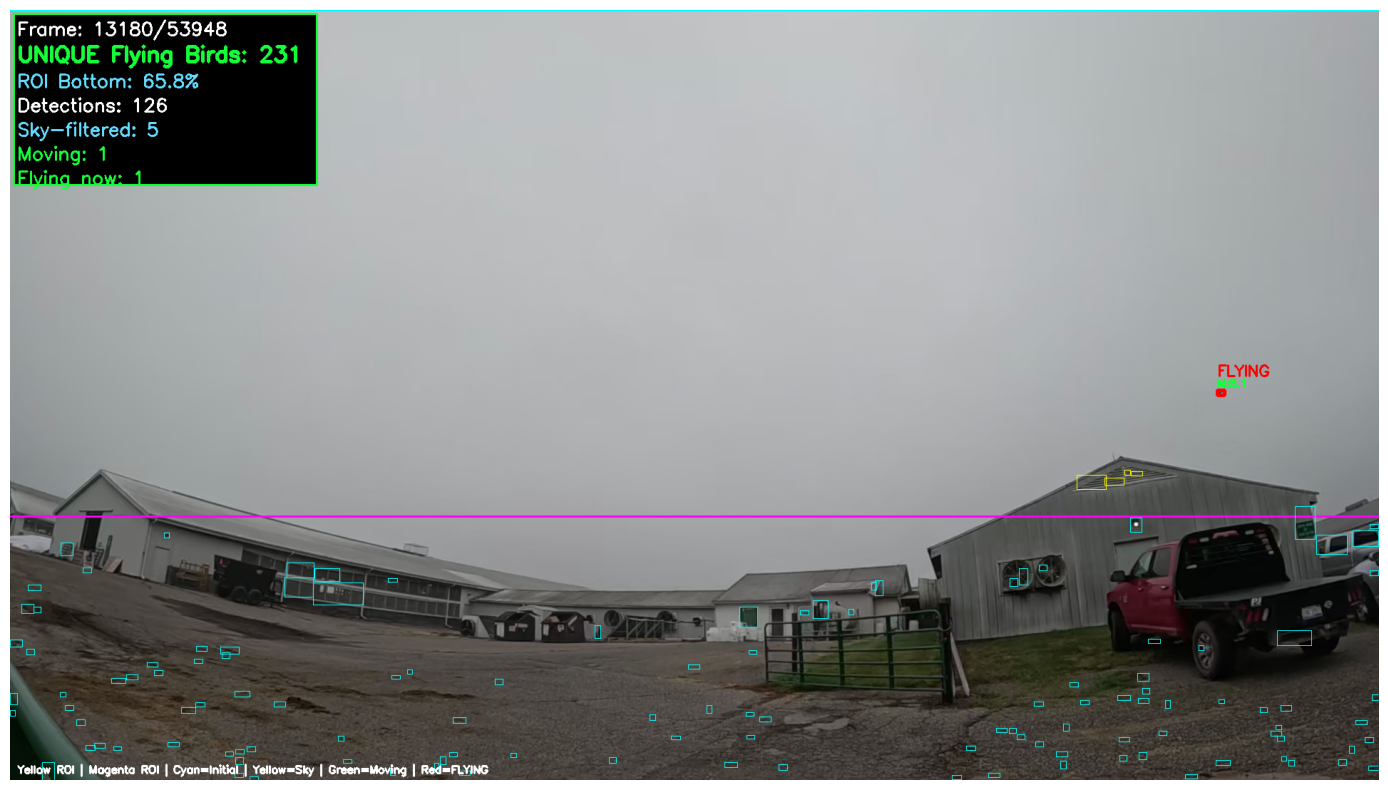

KeyboardInterrupt: 

In [10]:
# ============================================================================
# RUN THE BIRD COUNTER WITH VISUALIZATION
# ============================================================================

print("Bird Counter - Auto Threshold with Dynamic ROI")
print("=" * 60)
print("Features:")
print("- Dynamic ROI: Auto-adjusts based on horizon detection")
print("- Sky Color Detection: Multiple sky condition support")
print("- Cloud Rejection: Texture and edge analysis")
print("- Optical Flow: Motion-based discrimination")
print("- Flight Pattern: Temporal confirmation")
print("- Video Output: Annotated video with bounding boxes")
print("=" * 60)
print()

# Check if video exists
if os.path.exists(VIDEO_PATH):
    print(f"Video found: {VIDEO_PATH}")
    print()
    
    # Process video with visualization
    result = process_video_with_visualization(
        VIDEO_PATH,
        save_output=SAVE_OUTPUT_VIDEO,
        display_live=DISPLAY_LIVE_FRAMES,
        display_interval=DISPLAY_EVERY_N_FRAMES
    )
else:
    print(f"ERROR: Video file not found at: {VIDEO_PATH}")
    print("")
    print("Please update VIDEO_PATH in the configuration cell above.")
    print("Example: VIDEO_PATH = '/path/to/your/video.mp4'")